**Capstone Project 1** - Data Analysis using NumPy Matrices

Name: Rabiya Begum

Course: Data Science

Project Title: Analysis on NHANES Body Measurements using NumPy Matrix.

##Project Overview
This project analyses body measurement data of adult male and female participants using NumPy, Pandas, Matplotlib, and SciPy.  
The dataset is taken from the NHANES (National Health and Nutrition Examination Survey) study.

The project includes:
- Data loading and preprocessing  
- Statistical analysis of body measurements  
- Visualisation using histograms, boxplots, and scatterplot matrices  
- Computation of BMI and body proportion ratios  
- Standardisation using z-scores  
- Correlation analysis and interpretation  

The objective of this project is to apply matrix operations, statistical methods, and data visualisation techniques to real-world health data.

**Downloading the Dataset**

The required NHANES dataset files are downloaded from the official GitHub repository.

This ensures that the notebook is self-contained and can be executed on any system without the need for manual file uploads.

The datasets used in this project are:
1. nhanes_adult_male_bmx_2020.csv
2. nhanes_adult_female_bmx_2020.csv

These files contain body measurement data of adult male and female participants.


In [1]:
!wget -q https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv
!wget -q https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv

print("Datasets downloaded successfully!")


Datasets downloaded successfully!


**Importing Required Libraries**

In the below code cell the required Python libraries are imported for analyzing the data and visualisation.

The following libraries used in this project are:
1. NumPy: Used for numerical and matrix operations
2. Matplotlib: Used for visualisation of data and plotting graphs
3. Pandas: Used for handling data and data frame operations
4. SciPy: Used for statistical analysis

These libraries are required to perform the calculations and visualisations in this project.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

**Loading the Dataset into NumPy Matrices**

Here the downloaded CSV files are loaded into NumPy matrices.

The function `genfromtxt()` is used to read the data, skipping the header row.

Two matrices are created:
- 'male' - contains body measurements of adult male participants and
- 'female' - contains body measurements of adult female participants

Each matrix consists of seven columns - weight, height, upper arm length, upper leg length, arm circumference, hip circumference and waist circumference.


In [3]:
male = np.genfromtxt("nhanes_adult_male_bmx_2020.csv", delimiter=",", skip_header=1)
female = np.genfromtxt("nhanes_adult_female_bmx_2020.csv", delimiter=",", skip_header=1)

print("Male shape:", male.shape)
print("Female shape:", female.shape)

Male shape: (4082, 7)
Female shape: (4222, 7)


###The output
Male shape: (4082, 7) and

Female shape: (4222, 7) represents that

The male dataset consists of 4082 participants with 7 body measurement variables each and the female dataset consists of 4222 participants with 7 body measurement variables each.

**Histogram of Male and Female Body Weights with identical x-axis Limits**

The histograms are used to visualise the distribution of body weights for male and female participants.  
Missing values (NaN) are removed to ensure accurate visualisation.

On a single plot using `matplotlib.pyplot.subplot()`two histograms are plotted:
- For female the top subfigure shows the weight distribution.
- For male the bottom subfigure shows the weight distribution.

We call `matplotlib.pyplot.xlim` to make the xaxis limits identical for both subfigure.
These limits are determined based on the minimum and maximum weight values observed in both datasets.


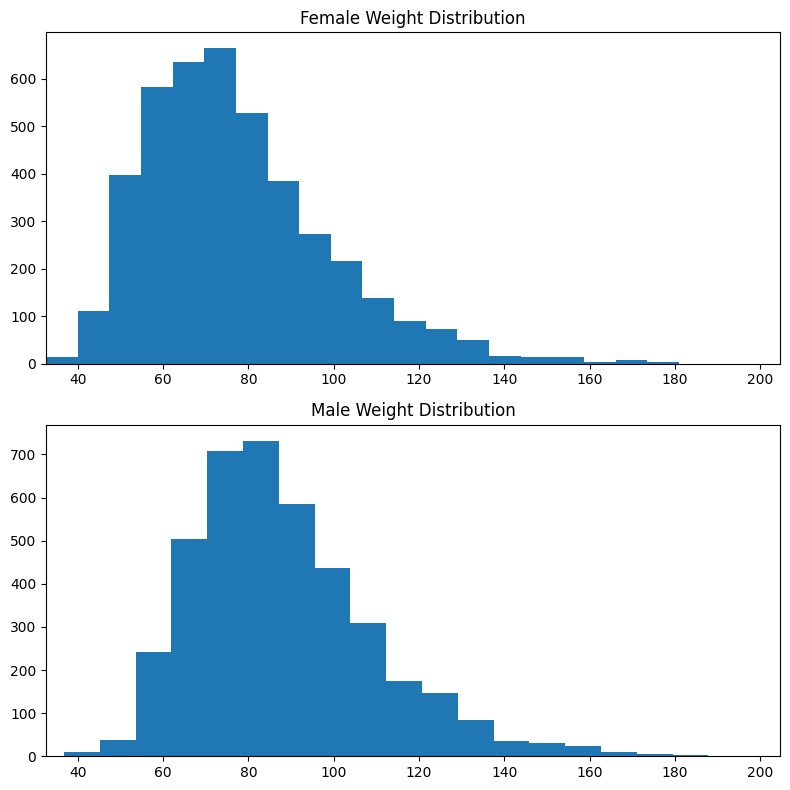

In [4]:
female_weights = female[:,0]
male_weights = male[:,0]

female_weights = female_weights[~np.isnan(female_weights)]
male_weights = male_weights[~np.isnan(male_weights)]

min_weight = min(female_weights.min(), male_weights.min())
max_weight = max(female_weights.max(), male_weights.max())

plt.figure(figsize=(8,8))

plt.subplot(2,1,1)
plt.hist(female_weights, bins=20)
plt.title("Female Weight Distribution")
plt.xlim(min_weight, max_weight)

plt.subplot(2,1,2)
plt.hist(male_weights, bins=20)
plt.title("Male Weight Distribution")
plt.xlim(min_weight, max_weight)

plt.tight_layout()
plt.show()

### Result
The histograms display the frequency distribution of body weights for female and male participants with the same x-axis scale.

It is observed that male participants  have higher body weight values compared to female participants.  
Both distribution shows right-skewed pattern, indicating that a smaller number of participants have very high body weights.

In general, the male weight distribution is shifted towards the higher values when compared to the female weight distribution.


##Box-and-Whisker Plot for Comparing Male and Female Body Weights

Here, a box-and-whisker plot is drawn using `matplotlib.pyplot.boxplot` to compare the distribution of body weights of male and female participants.

The boxplot function can be fed with a list of two vectors, `[female_weights, male_weights]`, which represent the body weight measurements of female and male participants respectively. This results in two boxes side by
side giving the male and female weights so that they can be compared to each other.

The box-and-whisker plot summarises the data by showing the median, interquartile range, spread of the distribution, and potential outliers for both male and female body weights.



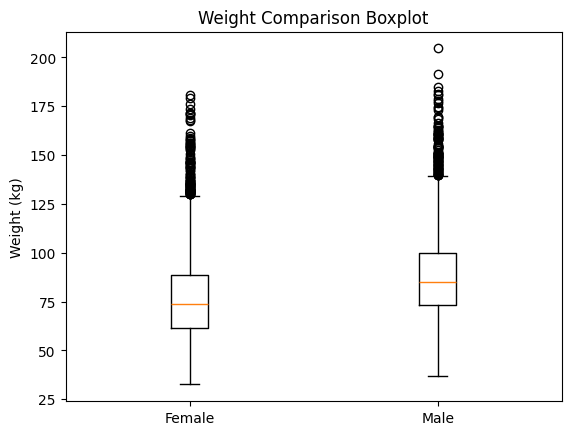

In [5]:
plt.boxplot([female_weights, male_weights], tick_labels=["Female", "Male"])
plt.title("Weight Comparison Boxplot")
plt.ylabel("Weight (kg)")
plt.show()

###Result

The box-and-whisker plot shows that the median body weight of male participants is higher than that of female participants.  
The interquartile range for males is slightly larger, indicating greater variability in male body weights.

The presence of a few outliers indicates that there are some participants with unusually high or low body weight values.  
Therefore, the male participants tend to be heavier than female participants on average.


**Basic numerical aggregates of the male and female weights**

The basic numerical aggregates of male and female body weights are calculated.  
These aggregates include measures of location, dispersion, and shape.

The following statistics are calculated:
- Measures of location - Mean and Median
- Measures of dispersion - Standard Deviation and Variance
- Measures of shape - Skewness and Kurtosis


In [6]:
def describe(name, data):
    print(f"\n{name} Weight Statistics")
    print("-" * 25)
    print("Mean     :", np.mean(data))
    print("Median   :", np.median(data))
    print("Std Dev  :", np.std(data))
    print("Variance :", np.var(data))
    print("Skewness :", stats.skew(data))
    print("Kurtosis :", stats.kurtosis(data))


describe("Female", female_weights)
describe("Male", male_weights)


Female Weight Statistics
-------------------------
Mean     : 77.40379057095475
Median   : 73.6
Std Dev  : 21.54250829019315
Variance : 464.07966343304065
Skewness : 1.03336107186799
Kurtosis : 1.4009683480659731

Male Weight Statistics
-------------------------
Mean     : 88.36454300416565
Median   : 85.0
Std Dev  : 21.418936717962495
Variance : 458.770850128082
Skewness : 0.9842810741662347
Kurtosis : 1.4742884754078238


###Result - Comparing the two distribution

From the calculated statistics it is observed that the average body weight i.e mean and median of male participants is higher than that of female participants.  

The standard deviation and variance values indicate that the male body weights shows slightly higher variability to that of the female body weights.  

The skewness values for both distributions are positive, which indicates that both male and female weight distributions are right-skewed. This means that smaller number of participants have very high body weight values.  

The kurtosis values suggest that both distributions have moderately heavy tails, indicating the presence of some extreme values.

Therefore, the male participants tend to be heavier on average and show slightly more dispersion in body weights as compared to the female participants.


**Adding Body Mass Index (BMI) as eight column to the female participants data matrix**

The Body Mass Index (BMI) is calculated for each female participant and added as a new column to the female data matrix.

BMI is calculated using the standard formula:

BMI = weight (kg) / [height (m)]²

Since height is given in centimeters, we first convert it into meters before calculating BMI.  
The calculated BMI values are then added as the eighth column to the existing female data matrix.


In [7]:
height_m = female[:,1] / 100
bmi = female[:,0] / (height_m**2)

female = np.column_stack((female, bmi))

###Result

After adding the BMI values the female data matrix now contains eight columns.

This appended matrix allows further analysis of BMI distribution and its relationship with other body measurements.


**Standardisation of the Female Dataset Using Z-Scores**

A standardised version of the female dataset is created by calculating the z-scores of each column.

Standardisation transforms the data such that each column has:
- Mean equal to 0
- Standard deviation equal to 1

This is achieved by converting each value into its corresponding z-score using the formula:

z = (x − μ) / σ

where μ is the mean and σ is the standard deviation of the column.

The resul of the standardised dataset is stored in a new matrix called `zfemale`.


In [8]:
zfemale = stats.zscore(female, nan_policy='omit')

##Result

The new matrix `zfemale` represents a standardised version of the female dataset where all columns are on the same scale.

This transformation removes the effect of different units and scales, making the data suitable for further statistical analysis.




**Scatterplot matrix (pairplot) for the standardised versions of body measurements of the females**

A scatterplot matrix (pairplot) is created for the standardised versions of female participants body measurements.

The following body measurements included:
- Height  
- Weight  
- Waist circumference  
- Hip circumference  
- Body Mass Index (BMI)  

The data is based on the standardised version of female `zfemale`. The selected columns are extracted and converted into a pandas DataFrame for visualisation.

This matrix allows pairwise comparison of all variables and helps in identifying patterns, trends, and relationships between different body measurements.


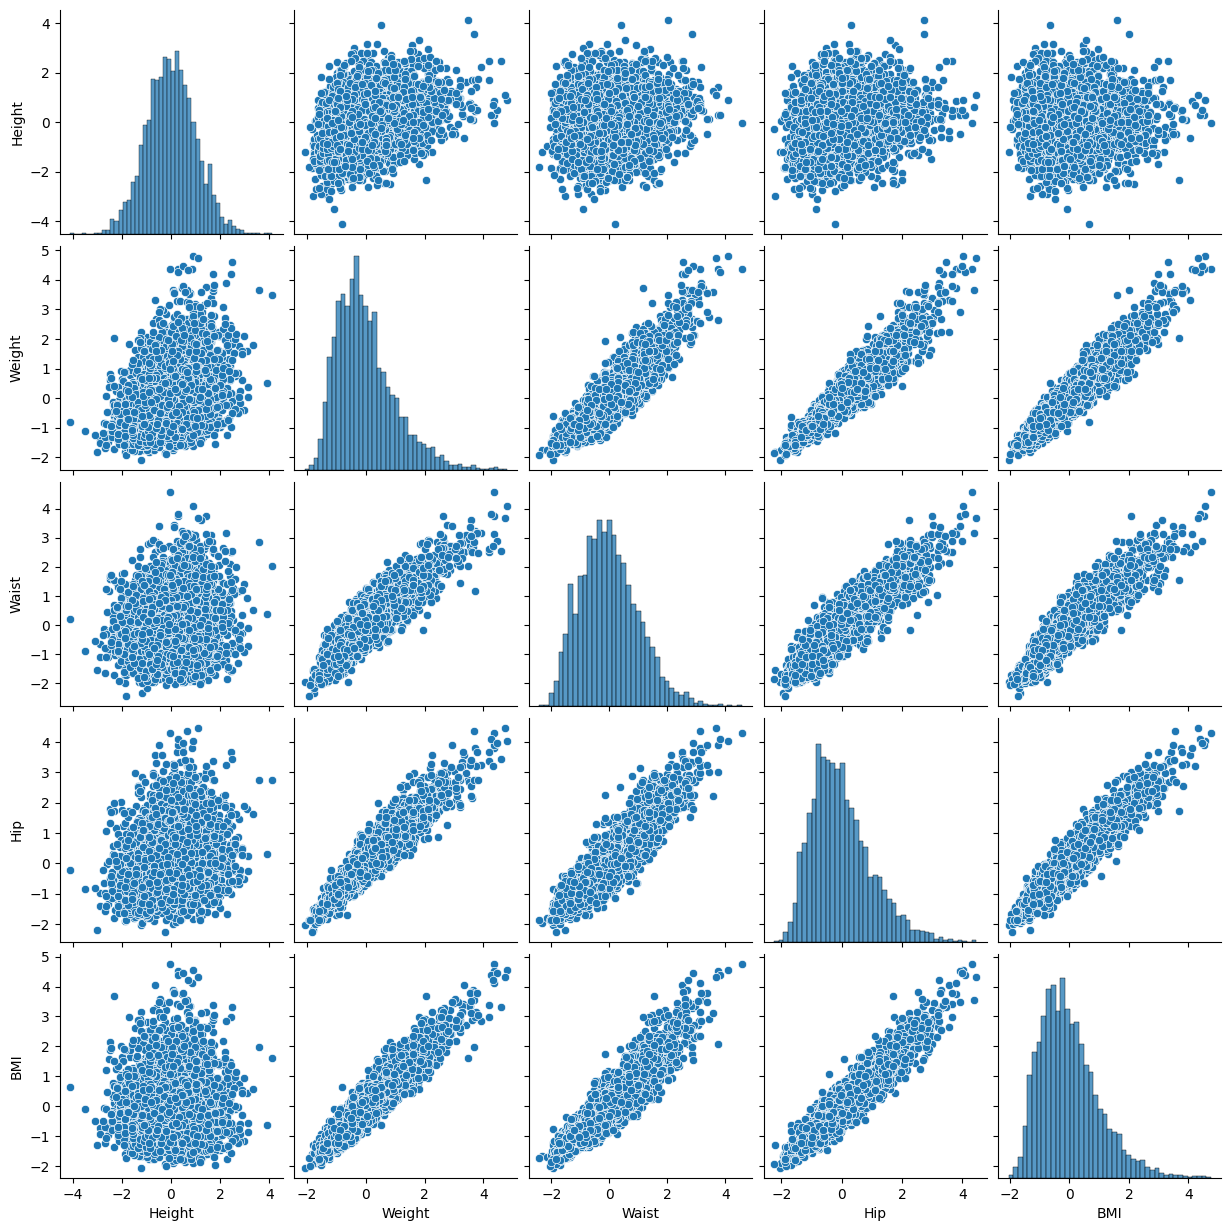

In [9]:
import seaborn as sns
data = zfemale[:,[1,0,6,5,7]]
df = pd.DataFrame(data, columns=["Height","Weight","Waist","Hip","BMI"])
sns.pairplot(df)
plt.show()

###Interpretation of the result

The scatterplot matrix shows clear positive relationships between weight, waist circumference, hip circumference, and BMI. This indicates that the participants with higher body weight tend to have higher waist and hip measurements and a higher BMI.

Height shows a weaker relationship with BMI as compared to the other measurements, indicating that BMI is more strongly influenced by body mass than the height .

Overall, the scatterplot matrix visually confirms the strong association between body fat related measurements among female participants.


**Correlation Analysis of Standardised Female Body Measurements**

Pearson's and Spearman's correlation coefficients are computed for the standardised female body measurements.

- Pearson's correlation coefficient measures the strength and direction of linear relationships between variables
- Spearman's correlation coefficient measures the strength and direction of monotonic relationships based on ranked data.

The correlation matrices are computed for the following variables:
- Height  
- Weight  
- Waist circumference  
- Hip circumference  
- Body Mass Index (BMI)  

These correlation coefficients provide a quantitative measure of how strongly different body measurements are related to each other.


In [10]:
print("Pearson Correlation:\n", df.corr(method='pearson'))
print("\nSpearman Correlation:\n", df.corr(method='spearman'))

Pearson Correlation:
           Height    Weight     Waist       Hip       BMI
Height  1.000000  0.345496  0.126547  0.202895  0.033077
Weight  0.345496  1.000000  0.904550  0.946553  0.945900
Waist   0.126547  0.904550  1.000000  0.897407  0.921198
Hip     0.202895  0.946553  0.897407  1.000000  0.944199
BMI     0.033077  0.945900  0.921198  0.944199  1.000000

Spearman Correlation:
           Height    Weight     Waist       Hip       BMI
Height  1.000000  0.338860  0.108587  0.205405  0.019897
Weight  0.338860  1.000000  0.900169  0.946634  0.937999
Waist   0.108587  0.900169  1.000000  0.888037  0.923114
Hip     0.205405  0.946634  0.888037  1.000000  0.934196
BMI     0.019897  0.937999  0.923114  0.934196  1.000000


###Interpretation of Correlation Results

The Pearson correlation matrix shows strong positive correlations between weight, waist circumference, hip circumference, and BMI. This indicates that these variables increase together in a linear manner.

Height shows weaker correlations with BMI and waist circumference, indicating that BMI is more strongly influenced by body mass than by height alone.

The Spearman correlation matrix shows a similar pattern of strong positive relationships, confirming that the associations between these variables are consistent even when considering their ranked values.

Overall, the correlation analysis confirms that body fat related measurements are highly correlated among female participants.


**Waist-to-Height Ratio and Waist-to-Hip Ratio Calculation**

Two important health-related body proportion indices are calculated for both male and female participants:

- Waist-to-Height Ratio (WTH)
- Waist-to-Hip Ratio (WHR)

These ratios are calculated using the following formulas:

- Waist-to-Height Ratio (WTH) = Waist Circumference / Height  
- Waist-to-Hip Ratio (WHR) = Waist Circumference / Hip Circumference  

The ratios are calculated for each participant using the existing waist, height, and hip measurements from the datasets.


In [11]:
female_wth = female[:,6] / female[:,1]
female_whr = female[:,6] / female[:,5]

male_wth = male[:,6] / male[:,1]
male_whr = male[:,6] / male[:,5]

###Result

The waist-to-height ratio and waist-to-hip ratio have been successfully calculated for both male and female participants.

These ratios are widely used as indicators of body fat distribution and potential health risk. Higher values indicate a greater concentration of abdominal fat which is associated with increased risk of cardiovascular and metabolic diseases.

The newly computed ratios can now be used for further comparative and statistical analysis between male and female participants.


In [12]:
female_wth = female_wth[~np.isnan(female_wth)]
male_wth = male_wth[~np.isnan(male_wth)]
female_whr = female_whr[~np.isnan(female_whr)]
male_whr = male_whr[~np.isnan(male_whr)]

**Box-and-Whisker Plot for Waist-to-Height and Waist-to-Hip Ratios**

A box-and-whisker plot is created to compare the distributions of two important body proportion indices for both male and female participants:

- Waist-to-Height Ratio (WtH)
- Waist-to-Hip Ratio (WHR)

Four boxplots are displayed side by side:
- Female Waist-to-Height Ratio (F WtH)
- Male Waist-to-Height Ratio (M WtH)
- Female Waist-to-Hip Ratio (F WHR)
- Male Waist-to-Hip Ratio (M WHR)

This visualisation allows a direct comparison of body fat distribution patterns between genders and between the two ratio measures.


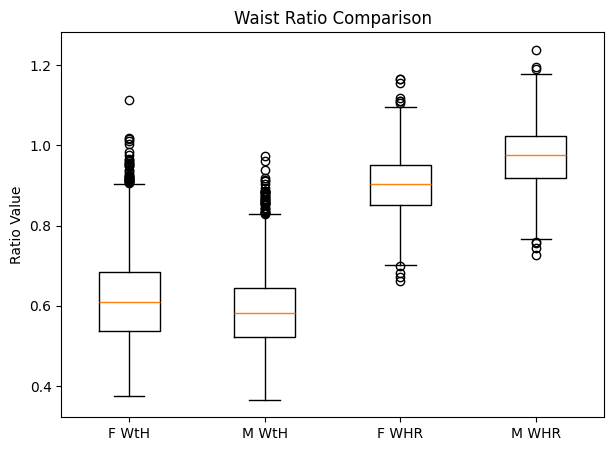

In [13]:
plt.figure(figsize=(7,5))

plt.boxplot([female_wth, male_wth, female_whr, male_whr],
            tick_labels=["F WtH", "M WtH", "F WHR", "M WHR"])

plt.title("Waist Ratio Comparison")
plt.ylabel("Ratio Value")
plt.show()

###Interpretation
From the box-and-whisker plot, it is observed that male participants have higher waist-to-height and waist-to-hip ratio values compared to that of female participants. This indicates higher concentration of abdominal fat among males.

The waist-to-height ratio shows slightly greater variability than that of waist-to-hip ratio for both genders, indicating that height plays a significant role in the distribution of waist measurements.

The interquartile ranges indicate moderate spread in the ratios, and the presence of some outliers suggests that a few participants have unusually high or low ratio values.

Therefore, the plot highlights the differences in body fat distribution between male and female participants.

**Advantages and Disadvantages of BMI, Waist-to-Height Ratio, and Waist-to-Hip Ratio**

###Body Mass Index (BMI)
Advantages:
- Simple and easy to calculate using height and weight.
- Widely used and accepted in medical and public health studies.

Disadvantages:
- Does not distinguish between muscle mass and fat mass.
- Does not reflect fat distribution in the body.
---
###Waist-to-Height Ratio (WtH)
Advantages:
- Better predictor of cardiovascular and metabolic risk than BMI.
- Simple to calculate and interpret.

Disadvantages:
- Does not consider overall body composition.
- Measurement errors in waist or height can affect accuracy.
---
###Waist-to-Hip Ratio (WHR)
Advantages:
- Indicates body fat distribution pattern (apple-shaped vs pear-shaped body).
- Useful for assessing risk of heart disease and diabetes.

Disadvantages:
- Does not reflect total body fat.
- May not accurately represent fat distribution in very lean or very obese individuals.




**Standardised Body Measurements for Participants with Lowest and Highest BMI**

The standardised body measurements of female participants with the lowest and highest Body Mass Index (BMI) values are examined.

The BMI values are extracted from the female dataset, and the participants are sorted based on their BMI using `numpy.argsort`.  
From the sorted list, the following groups are selected:

- The 5 participants with the lowest BMI  
- The 5 participants with the highest BMI  

The corresponding rows from the standardised dataset `zfemale` are printed for analysis.  
Each row represents the standardised body measurements of one participant.


In [14]:
bmi_values = female[:,7]
order = np.argsort(bmi_values)

print("Lowest BMI:\n", zfemale[order[:5]])
print("\nHighest BMI:\n", zfemale[order[-5:]])

Lowest BMI:
 [[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]]

Highest BMI:
 [[ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]
 [ 4.36328993 -0.03353037 -0.05585782 -0.17357792  2.77942222  4.31569054
   4.57029862  4.76243308]
 [        nan         nan         nan         nan         nan    

###Interpretation

The participants with the lowest BMI values show negative or below-average z-scores for weight, waist circumference, hip circumference, and BMI, indicating leaner body composition compared to the overall population.

In contrast to, the participants with the highest BMI values exhibit high positive z-scores for weight, waist circumference, hip circumference, and BMI. This indicates significantly higher body fat and body mass compared to the average participant.

Height values vary across both groups, confirming that BMI is influenced more strongly by body mass and waist measurements than by height.

Overall, the results clearly demonstrate how standardisation highlights relative differences in body composition among participants.